# Importance Sampling for Failure Probability Estimation

We want to estimate the probability that an aircraft trajectory **fails** (violates a safety specification) under a **nominal** sensor/initial-condition distribution $p_\text{nom}$.

Direct Monte Carlo under $p_\text{nom}$ is inefficient when failures are rare.
Instead we sample under a **proposal** distribution $q$ that is broader (higher noise, heavier tails), then correct with importance weights:

$$
\hat{p}_f^{\,\text{IS}}
  = \frac{1}{N}\sum_{i=1}^{N} \frac{p_\text{nom}(\xi_i)}{q(\xi_i)}\,\mathbf{1}[\text{failure}(\xi_i)],
  \qquad \xi_i \sim q
$$

Because the likelihoods are computed in log-space during the rollout, we have
$\log w_i = \log p_\text{nom}(\xi_i) - \log q(\xi_i)$ available directly as
`trajectory_log_importance_weight`.

**Self-normalised (SN-IS) estimator** — more stable in practice:

$$
\hat{p}_f^{\,\text{SN}}
  = \frac{\sum_i \tilde{w}_i\,\mathbf{1}[\text{failure}_i]}{\sum_i \tilde{w}_i},
  \qquad \tilde{w}_i = \exp(\log w_i)
$$

**Effective Sample Size** — measures how many i.i.d. nominal samples the weighted
sample is worth:

$$
\text{ESS} = \frac{\left(\sum_i \tilde{w}_i\right)^2}{\sum_i \tilde{w}_i^2}
$$


In [6]:
import io
import contextlib
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from main import run_agent_env_sensor_loop


/Users/andrewzchen/.conda/envs/cs228v_finalproject/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Failure Specification

A trajectory is a **failure** if any of the following occur:
- Altitude exits the safe band $[z_\text{min},\, z_\text{max}]$
- Pitch angle exits $[\theta_\text{min},\, \theta_\text{max}]$
- The simulation terminates early for any reason (e.g. ground contact)

`run_agent_env_sensor_loop` already checks the specification online via the
`specification` dict and sets `violated_spec = True` / `terminated_early = True`
when the trajectory leaves the safe region.


In [46]:
SPECIFICATION = dict(
    z_min=0.2,
    z_max=0.6,
    pitch_min=-np.deg2rad(15.0),
    pitch_max=np.deg2rad(15.0),
)

Z_TARGET = 0.4   # target altitude (m)
N_STEPS  = 2000  # simulation steps at dt = 0.01 s  →  20 s per rollout


def is_failure(result: dict) -> bool:
    """Return True if the rollout violates the safety specification."""
    return bool(result["terminated_early"] or result["violated_spec"])


## Proposal and Nominal Distributions

The **nominal** distribution represents the real operating conditions we care about.
The **proposal** (rollout) distribution is the biased sampling distribution designed
to generate failures more often.

Here we widen `sigma_A`, `sigma_eps`, and `p_penetration` relative to nominal, and
slightly spread the initial altitude uncertainty `sigma_z0`.
Every rollout is scored under *both* distributions simultaneously (online dual
log-likelihood tracking in `LiDARSensor`).


In [ ]:
# ── Proposal / sampling distribution ─────────────────────────────────────────
# Deliberately wider noise to oversample near-failure trajectories.
# ROLLOUT_ARGS = dict(
#     mu_z0=0.8,
#     sigma_z0=0.25,         # wider initial altitude spread → more exceedance events
#     sensor_args=dict(
#         mu_A=0.1,
#         sigma_A=0.15,      # larger amplitude uncertainty
#         mu_k=2 * np.pi,
#         sigma_k=0.5,
#         sigma_eps=0.01,
#         p_penetration=0.05,
#         alpha_min=0.10,
#         alpha_max=10.0,
#         perfect_sensing=False,
#     ),
# )

ROLLOUT_ARGS = dict(
    mu_z0=0.4,
    sigma_z0=0.02,
    sensor_args=dict(
        # Proposal / sampling distribution
        mu_A=0.0,
        sigma_A=0.1,
        mu_k=2 * np.pi,  # wavelength = k / 2pi
        sigma_k=0.5,
        sigma_eps=0.02,
        p_penetration=0.1,
        alpha_min=0.10,
        alpha_max=5.0,
        perfect_sensing=False,
    ),
)

# ── Nominal / target distribution ─────────────────────────────────────────────
# The real-world conditions we want to estimate failure probability under.
# NOMINAL_ROLLOUT_ARGS = dict(
#     mu_z0=0.8,
#     sigma_z0=0.10,
#     sensor_args=dict(
#         mu_A=0.0,
#         sigma_A=0.05,
#         mu_k=2 * np.pi,
#         sigma_k=0.5,
#         sigma_eps=0.01,
#         p_penetration=0.05,
#         alpha_min=0.10,
#         alpha_max=10.0,
#         perfect_sensing=False,
#     ),
# )

NOMINAL_ROLLOUT_ARGS = dict(
    mu_z0=0.4,
    sigma_z0=0.005,
    sensor_args=dict(
        # Nominal / target distribution used for importance-sampling weights
        mu_A=0.0,
        sigma_A=0.05,
        mu_k=2 * np.pi,
        sigma_k=0.5,
        sigma_eps=0.005,
        p_penetration=0.05,
        alpha_min=0.10,
        alpha_max=5.0,
        perfect_sensing=False,
    ),
)

N_ROLLOUTS = 50   # total number of IS rollouts (increase for tighter estimates)


## Run Rollouts Under the Proposal Distribution

Each rollout produces:
- `trajectory_log_importance_weight` = $\log p_\text{nom}(\xi) - \log q(\xi)$  (computed online)
- `violated_spec` / `terminated_early` — failure flag


In [ ]:
records = []

for i in tqdm(range(N_ROLLOUTS), desc="IS rollouts"):
    # Suppress simulator stdout/stderr for cleaner notebook output
    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        result = run_agent_env_sensor_loop(
            rollout_args=NOMINAL_ROLLOUT_ARGS,
            nominal_rollout_args=NOMINAL_ROLLOUT_ARGS,
            z_target=Z_TARGET,
            n_steps=N_STEPS,
            seed=i,
            enable_lateral_damper=True,
            use_ekf_pid_controller=True,
            specification=SPECIFICATION,
            ground_effect_enabled=True,
            save_trajectory_plot=False,
        )

    records.append({
        "seed":                              i,
        "failed":                            is_failure(result),
        "violated_spec":                     result["violated_spec"],
        "terminated_early":                  result["terminated_early"],
        "termination_type":                  result.get("termination_type"),
        "termination_step":                  result.get("termination_step"),
        "z0_sampled":                        result["z0_sampled"],
        "log_w":                             result["trajectory_log_importance_weight"],
        "log_likelihood_rollout":            result["trajectory_log_likelihood_rollout"],
        "log_likelihood_nominal":            result["trajectory_log_likelihood_nominal"],
    })

print(f"\nCompleted {N_ROLLOUTS} rollouts.")
print(f"  Observed failures (under proposal): {sum(r['failed'] for r in records)}")


IS rollouts:   6%|▌         | 3/50 [00:19<05:06,  6.52s/it]

## Importance Weights and ESS

We use the **log-sum-exp** (LSE) trick for numerical stability when normalising:

$$
w_i = \frac{\exp(\log \tilde{w}_i)}{\sum_j \exp(\log \tilde{w}_j)}
    = \exp\!\left(\log \tilde{w}_i - \mathrm{LSE}(\{\log \tilde{w}_j\})\right)
$$

**ESS** close to $N$ means the proposal is well-matched to the nominal.
A low ESS (say $< 0.1 N$) signals a poor proposal — the estimate will be
dominated by a handful of high-weight samples.


In [42]:
def logsumexp_np(values: np.ndarray) -> float:
    """Numerically stable log-sum-exp."""
    values = np.asarray(values, dtype=float)
    if values.size == 0:
        return -np.inf
    vmax = np.max(values)
    if not np.isfinite(vmax):
        return -np.inf
    return float(vmax + np.log(np.sum(np.exp(values - vmax))))


log_weights = np.array([r["log_w"] for r in records], dtype=float)
failed_mask = np.array([r["failed"] for r in records], dtype=bool)
failed = failed_mask.astype(float)

# ── Normalised weights (self-normalised IS) ───────────────────────────────────
log_w_norm = log_weights - logsumexp_np(log_weights)
weights_norm = np.exp(log_w_norm)   # sums to ~1

# ── Scaled raw weights for diagnostics / plotting only ────────────────────────
# (scaled by max log weight to avoid underflow)
weights_raw_scaled = np.exp(log_weights - np.max(log_weights))

# ── Effective Sample Size (scale-invariant form) ──────────────────────────────
ESS = (weights_raw_scaled.sum() ** 2) / np.sum(weights_raw_scaled ** 2)
ESS_frac = ESS / N_ROLLOUTS

print(f"ESS        : {ESS:.1f}  /  {N_ROLLOUTS}  (fraction: {ESS_frac:.2%})")
print(f"log w  min : {log_weights.min():.2f}")
print(f"log w  max : {log_weights.max():.2f}")
print(f"log w  mean: {log_weights.mean():.2f}")
print(f"max normalised weight: {weights_norm.max():.3e}")


ESS        : 50.0  /  50  (fraction: 100.00%)
log w  min : 0.00
log w  max : 0.00
log w  mean: 0.00
max normalised weight: 2.000e-02


## Failure Probability Estimates


In [43]:
n_failures = int(failed_mask.sum())

# ── Naive Monte Carlo (under proposal, not corrected) ─────────────────────────
p_mc_proposal = failed.mean()

if n_failures == 0:
    log_p_IS_unnorm = -np.inf
    log_p_IS_SN = -np.inf
    p_IS_unnorm = 0.0
    p_IS_SN = 0.0
else:
    log_num_fail = logsumexp_np(log_weights[failed_mask])
    log_den_all = logsumexp_np(log_weights)

    # IS unnormalised estimator: (1/N) Σ w_i * 1[fail_i]
    log_p_IS_unnorm = log_num_fail - np.log(N_ROLLOUTS)
    p_IS_unnorm = float(np.exp(log_p_IS_unnorm)) if log_p_IS_unnorm > -745 else 0.0

    # Self-normalised IS estimator: Σ w_i 1[fail_i] / Σ w_i
    log_p_IS_SN = log_num_fail - log_den_all
    p_IS_SN = float(np.exp(log_p_IS_SN)) if log_p_IS_SN > -745 else 0.0

print("=" * 64)
print(f"  N rollouts                   : {N_ROLLOUTS}")
print(f"  Observed failures (proposal) : {n_failures}  ({100*p_mc_proposal:.1f}%)")
print("-" * 64)
print(f"  Naive MC (proposal dist)     : {p_mc_proposal:.6f}")
print(f"  IS unnormalised              : {p_IS_unnorm:.6e}   (log={log_p_IS_unnorm:.2f})")
print(f"  IS self-normalised (SN-IS)   : {p_IS_SN:.6e}   (log={log_p_IS_SN:.2f})")
print("-" * 64)
print(f"  ESS                          : {ESS:.1f}  ({ESS_frac:.1%} of N)")
print("=" * 64)

if ESS_frac < 0.10:
    print("\n⚠  Low ESS — consider a better proposal distribution.")
elif ESS_frac < 0.30:
    print("\n⚠  Moderate ESS — estimates may have high variance.")
else:
    print("\n✓  ESS looks healthy.")

if np.isfinite(log_p_IS_SN) and p_IS_SN == 0.0:
    print("\nNote: SN-IS underflowed in linear space; use the logged value above.")
if np.isfinite(log_p_IS_unnorm) and p_IS_unnorm == 0.0:
    print("Note: unnormalised IS underflowed in linear space; use the logged value above.")


  N rollouts                   : 50
  Observed failures (proposal) : 1  (2.0%)
----------------------------------------------------------------
  Naive MC (proposal dist)     : 0.020000
  IS unnormalised              : 2.000000e-02   (log=-3.91)
  IS self-normalised (SN-IS)   : 2.000000e-02   (log=-3.91)
----------------------------------------------------------------
  ESS                          : 50.0  (100.0% of N)

✓  ESS looks healthy.


## Visualisations

### Log-weight histogram
A well-centred, narrow distribution (log weights close to 0) indicates a
proposal that closely matches the nominal.  Large negative weights mean those
samples contribute little; large positive weights dominate the estimate.

### Convergence plot
Shows how the IS and naive-MC estimates evolve as we accumulate more samples.
The IS estimate should converge faster to the true nominal failure probability
when the proposal successfully oversamples failures.


In [45]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# ── 1. Log-weight histogram ───────────────────────────────────────────────────
ax = axes[0]
ax.hist(log_weights, bins=30, color="steelblue", edgecolor="white", alpha=0.85)
ax.axvline(0.0, color="black", linestyle="--", linewidth=1, label="log w = 0")
ax.set_xlabel("Log importance weight  $\\log w_i$")
ax.set_ylabel("Count")
ax.set_title("Distribution of log importance weights")
ax.legend()

# ── 2. Normalised weight histogram ───────────────────────────────────────────
ax = axes[1]
ax.hist(weights_norm, bins=30, color="darkorange", edgecolor="white", alpha=0.85)
ax.axvline(1.0 / N_ROLLOUTS, color="black", linestyle="--", linewidth=1,
           label="Uniform weight 1/N")
ax.set_xlabel("Normalised weight $w_i$")
ax.set_ylabel("Count")
ax.set_title("Normalised importance weights")
ax.legend()

# ── 3. Cumulative failure probability estimate (log-space stable) ─────────────
ax = axes[2]
ns = np.arange(1, N_ROLLOUTS + 1)

# Running naive MC (under proposal)
p_mc_running = np.cumsum(failed) / ns

# Running IS and SN-IS in log space
running_log_num_fail = np.full(N_ROLLOUTS, -np.inf, dtype=float)
running_log_den_all = np.full(N_ROLLOUTS, -np.inf, dtype=float)

log_num = -np.inf
log_den = -np.inf
for i in range(N_ROLLOUTS):
    log_den = np.logaddexp(log_den, log_weights[i])
    running_log_den_all[i] = log_den

    if failed_mask[i]:
        log_num = np.logaddexp(log_num, log_weights[i])
    running_log_num_fail[i] = log_num

p_IS_running = np.exp(running_log_num_fail - np.log(ns))
p_SN_running = np.exp(running_log_num_fail - running_log_den_all)

ax.plot(ns, p_mc_running, "k--", linewidth=1.2, label="Naive MC (proposal)")
ax.plot(ns, p_IS_running, "steelblue", linewidth=1.4, label="IS unnormalised")
ax.plot(ns, p_SN_running, "darkorange", linewidth=1.4, label="SN-IS")
ax.set_xlabel("Number of rollouts")
ax.set_ylabel("Estimated failure probability")
ax.set_title("Convergence of failure probability estimates")
ax.legend()

plt.tight_layout()
plt.savefig("plots/is_failure_probability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved to plots/is_failure_probability.png")


Plot saved to plots/is_failure_probability.png


/var/folders/7s/xg01j8rs6lj189rx59yby1xr0000gn/T/ipykernel_2495/301323362.py:56: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


## Most Important Failure

Re-run the single rollout with the **highest IS weight among failures** and save
its trajectory plot.  This is the failure scenario that contributes most to the
IS failure probability estimate under the nominal distribution.


Most important failure: rollout 28  (seed=28,  log w=-7.634)
  z0 sampled              : 0.4983 m
  termination type        : spec_violation
  termination step        : 0


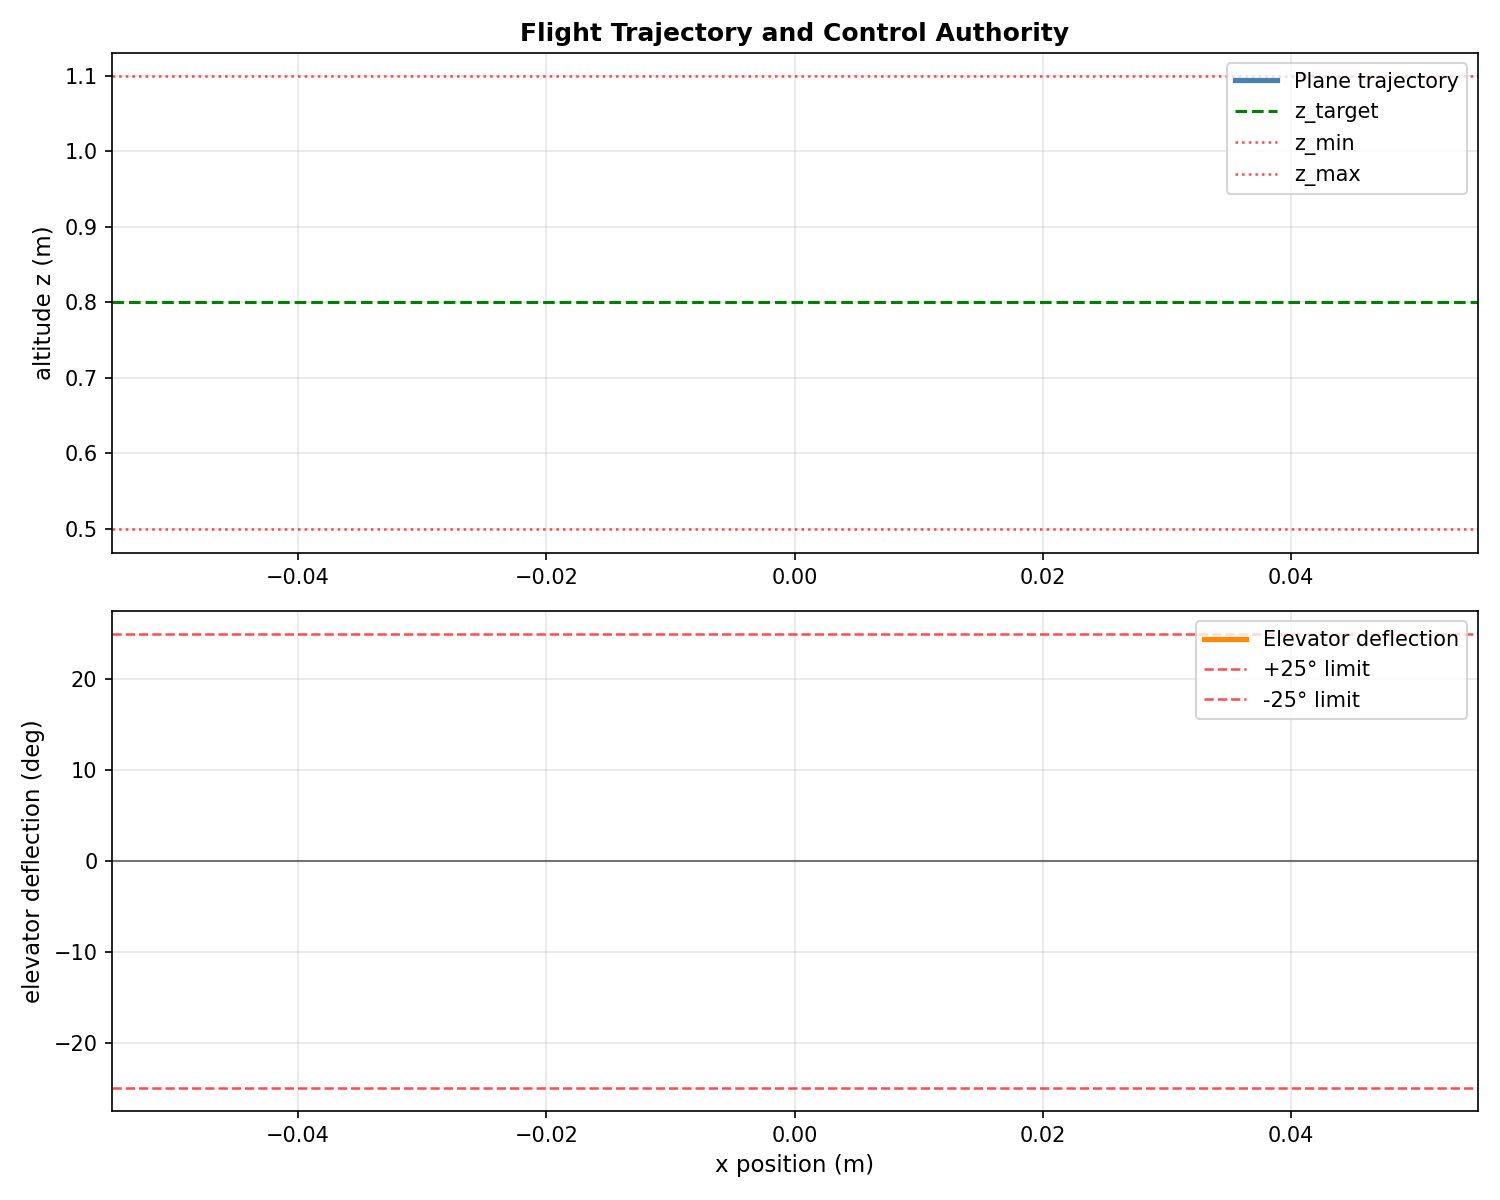

In [ ]:
from IPython.display import Image, display

failure_indices = np.where(failed_mask)[0]

if len(failure_indices) == 0:
    print("No failures observed — try increasing N_ROLLOUTS or widening the proposal.")
else:
    # Highest log weight among failures (same ordering as highest raw weight)
    best_idx = failure_indices[np.argmax(log_weights[failure_indices])]
    best_seed = records[best_idx]["seed"]
    best_logw = records[best_idx]["log_w"]

    print(f"Most important failure: rollout {best_idx}  (seed={best_seed}, log w={best_logw:.3f})")
    print(f"  z0 sampled              : {records[best_idx]['z0_sampled']:.4f} m")
    print(f"  termination type        : {records[best_idx]['termination_type']}")
    print(f"  termination step        : {records[best_idx]['termination_step']}")

    plot_path = "plots/is_most_important_failure.png"

    buf = io.StringIO()
    with contextlib.redirect_stdout(buf), contextlib.redirect_stderr(buf):
        result_best = run_agent_env_sensor_loop(
            rollout_args=ROLLOUT_ARGS,
            nominal_rollout_args=NOMINAL_ROLLOUT_ARGS,
            z_target=Z_TARGET,
            n_steps=N_STEPS,
            seed=best_seed,
            enable_lateral_damper=True,
            use_ekf_pid_controller=True,
            specification=SPECIFICATION,
            ground_effect_enabled=True,
            save_trajectory_plot=True,
            trajectory_plot_path=plot_path,
        )

    if result_best.get("trajectory_plot", {}).get("saved", False):
        display(Image(filename=plot_path))
    else:
        print("Could not save trajectory plot:", result_best.get("trajectory_plot"))
